### `Healthcare Stroke Prediction Analysis`

###### `According to World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths. The dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases and smoking status. Each row in the data provides relevant information about the patient.`


#### `Importing Libraries and Dataset`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

import plotly.express as px

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


In [41]:
stroke_prediction = pd.read_csv("../Dataset/healthcare-dataset-stroke-data.csv")

stroke_prediction.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


`Summary Statistics`


In [42]:
stroke_prediction.describe()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


`Understanding Target Column (stroke)`

In [43]:
stroke_prediction['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

`Checking for Missing Values`

In [44]:
stroke_prediction.isnull().sum().sort_values(ascending=False)

bmi                  201
id                     0
age                    0
gender                 0
hypertension           0
heart_disease          0
work_type              0
ever_married           0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64

`Handling Missing Values on bmi`

In [45]:
stroke_prediction['bmi'] = stroke_prediction['bmi'].fillna(stroke_prediction['bmi'].median())

stroke_prediction.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


`Dropping Patients ID Column`

In [46]:
stroke_prediction = stroke_prediction.drop(['id'], axis=1)
stroke_prediction.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


`Feature Engineering`

In [47]:
# cardiovascular risks

stroke_prediction['cardio_risk'] = stroke_prediction['hypertension'] + stroke_prediction['heart_disease']

# log glucose

stroke_prediction['log_glucose'] = np.log1p(stroke_prediction['avg_glucose_level'])

In [48]:
# bmi categories

bins = [0, 18.5, 25.0, 30.0, float('inf')]
labels = ['Underweight', 'Normal weight', 'Overweight', 'Obese']

stroke_prediction['bmi_category'] = pd.cut(stroke_prediction['bmi'], bins=bins, labels=labels, right=False)

`Handling Outliers`

In [49]:
q1 = stroke_prediction.select_dtypes(include=['number']).quantile(0.25)
q3 = stroke_prediction.select_dtypes(include=['number']).quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print(f'\n ==== Lower Bound ==== \n {lower_bound}')
print(f'\n ==== Upper Bound ==== \n {upper_bound}')


 ==== Lower Bound ==== 
 age                 -29.000000
hypertension          0.000000
heart_disease         0.000000
avg_glucose_level    21.977500
bmi                  10.300000
stroke                0.000000
cardio_risk           0.000000
log_glucose           3.781041
dtype: float64

 ==== Upper Bound ==== 
 age                  115.000000
hypertension           0.000000
heart_disease          0.000000
avg_glucose_level    169.357500
bmi                   46.300000
stroke                 0.000000
cardio_risk            0.000000
log_glucose            5.324519
dtype: float64


In [50]:
for cols in stroke_prediction.select_dtypes(include='number').columns:
    mask = (stroke_prediction[cols] < lower_bound[cols]) | (stroke_prediction[cols] > upper_bound[cols])
    count = mask.sum()
    if count > 0:
        print(f'{cols} : {count} outliers | '
              f'bounds=[{lower_bound[cols]:.2f}, {upper_bound[cols]:.2f}] | '
              f'actual_min={lower_bound[cols].min():.2f}, actual_max={upper_bound[cols].max():.2f}')

hypertension : 498 outliers | bounds=[0.00, 0.00] | actual_min=0.00, actual_max=0.00
heart_disease : 276 outliers | bounds=[0.00, 0.00] | actual_min=0.00, actual_max=0.00
avg_glucose_level : 627 outliers | bounds=[21.98, 169.36] | actual_min=21.98, actual_max=169.36
bmi : 126 outliers | bounds=[10.30, 46.30] | actual_min=10.30, actual_max=46.30
stroke : 249 outliers | bounds=[0.00, 0.00] | actual_min=0.00, actual_max=0.00
cardio_risk : 710 outliers | bounds=[0.00, 0.00] | actual_min=0.00, actual_max=0.00
log_glucose : 384 outliers | bounds=[3.78, 5.32] | actual_min=3.78, actual_max=5.32


`Data Visualization`

In [51]:
plt.figure(figsize=(22, 10))

figure = px.box(
    stroke_prediction.select_dtypes(include=['number']),
    orientation='h',
    title='Outlier Visualization'
)
figure.show()
plt.show()

<Figure size 2200x1000 with 0 Axes>

Distribution Across Gender and Age with Hypertension

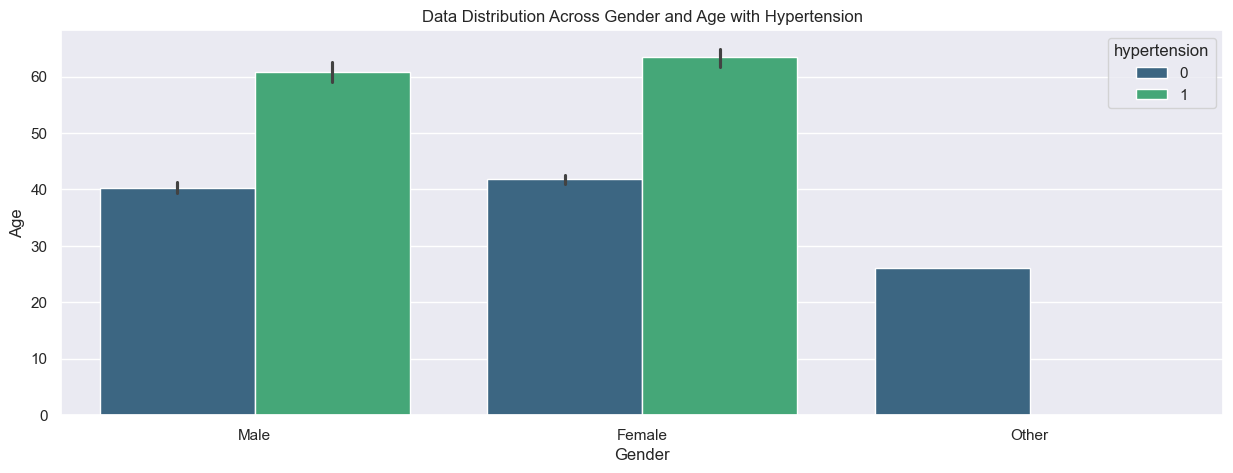

In [52]:
plt.figure(figsize=(15, 5))
sns.barplot(data=stroke_prediction, x='gender', y='age', palette='viridis', hue='hypertension')

plt.title('Data Distribution Across Gender and Age with Hypertension')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

Distribution Across Gender and Age with Heart Disease

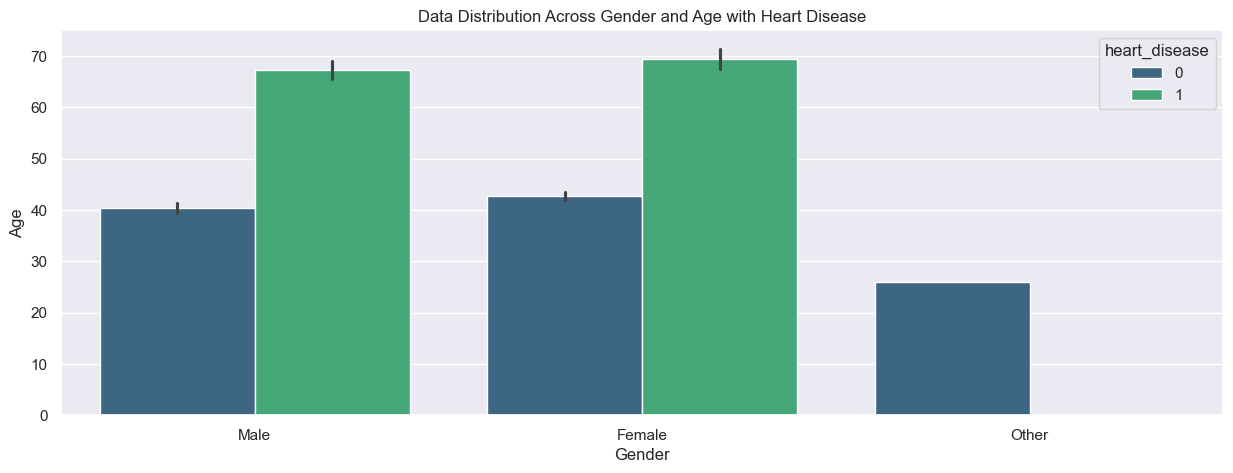

In [53]:
plt.figure(figsize=(15, 5))
sns.barplot(data=stroke_prediction, x='gender', y='age', palette='viridis', hue='heart_disease')

plt.title('Data Distribution Across Gender and Age with Heart Disease')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

Distribution Across Work type

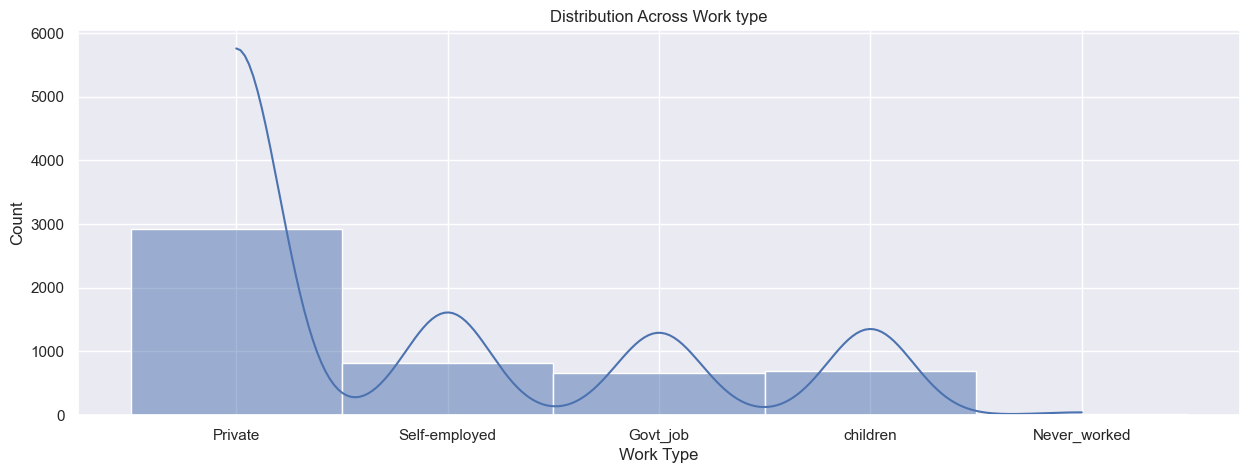

In [54]:
plt.figure(figsize=(15, 5))
sns.histplot(data=stroke_prediction, x='work_type', kde=True, palette='viridis')

plt.title('Distribution Across Work type')
plt.xlabel('Work Type')
plt.show()

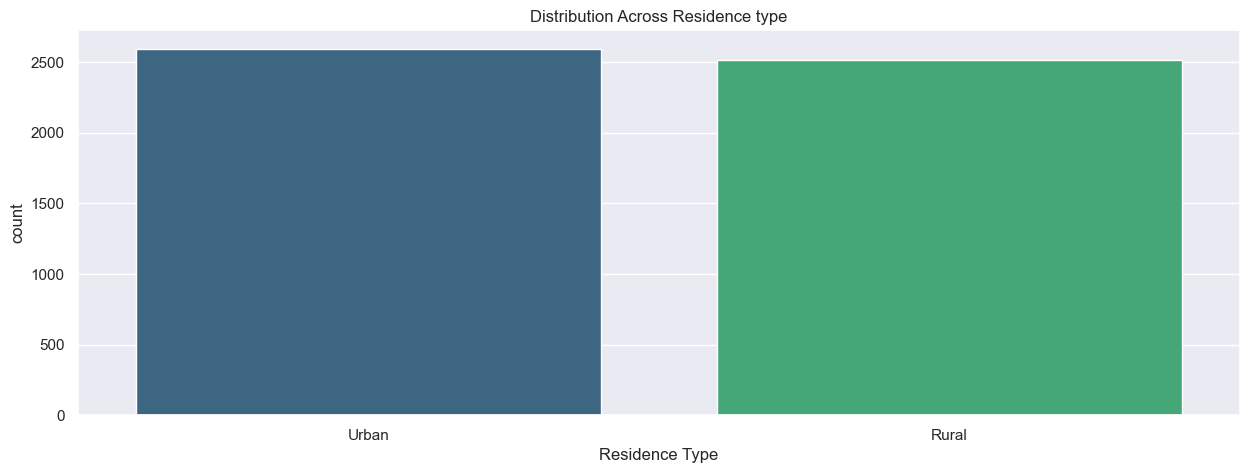

In [55]:
plt.figure(figsize=(15, 5))
sns.countplot(data=stroke_prediction, x='Residence_type', palette='viridis', hue='Residence_type')

plt.title('Distribution Across Residence type')
plt.xlabel('Residence Type')
plt.show()

Distribution Across Smoking Status with Gender

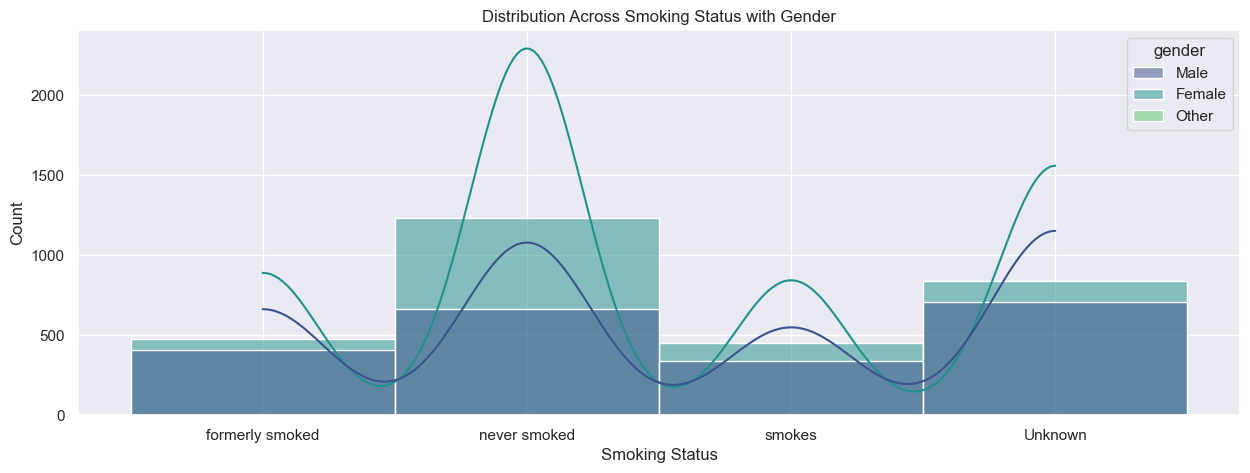

In [56]:
plt.figure(figsize=(15, 5))
sns.histplot(data=stroke_prediction, x='smoking_status', palette='viridis', hue='gender', kde=True)

plt.title('Distribution Across Smoking Status with Gender')
plt.xlabel('Smoking Status')
plt.show()

Distribution Across Work type with Gender

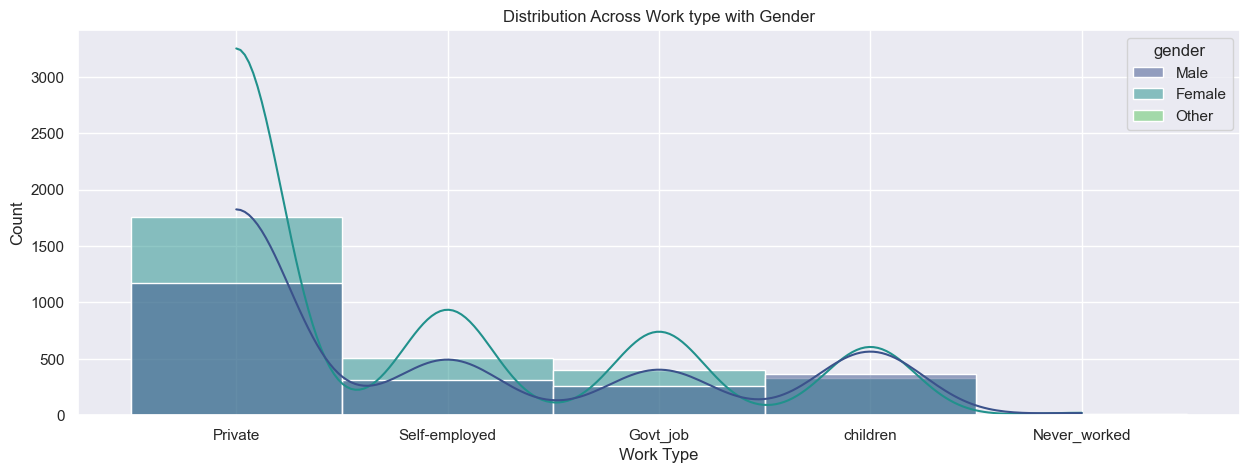

In [57]:
plt.figure(figsize=(15, 5))
sns.histplot(data=stroke_prediction, x='work_type', palette='viridis', hue='gender', kde=True)

plt.title('Distribution Across Work type with Gender')
plt.xlabel('Work Type')
plt.show()

Distribution Across Age and BMI with Gender

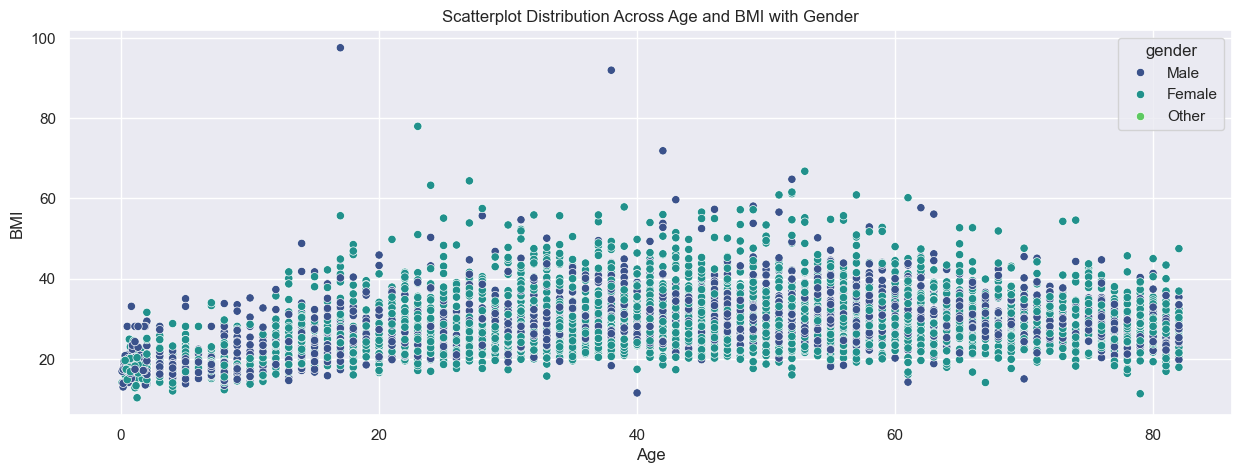

In [58]:
plt.figure(figsize=(15, 5))
sns.scatterplot(data=stroke_prediction, x='age', y='bmi', palette='viridis', hue='gender')

plt.title('Scatterplot Distribution Across Age and BMI with Gender')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()


Distribution Across Average Glucose Level and BMI with Gender

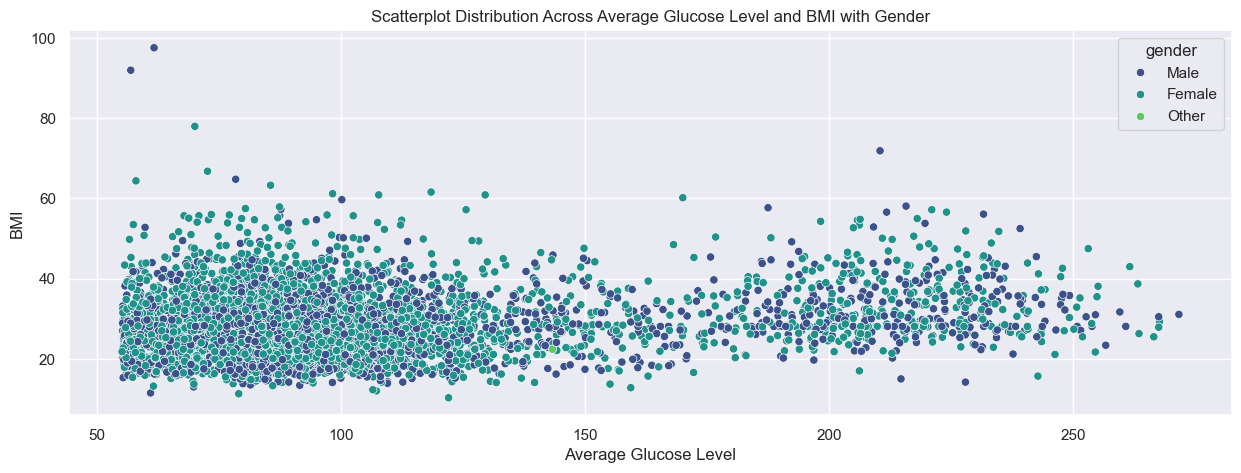

In [59]:
plt.figure(figsize=(15, 5))

sns.scatterplot(data=stroke_prediction, x='avg_glucose_level', y='bmi', palette='viridis', hue='gender')

plt.title('Scatterplot Distribution Across Average Glucose Level and BMI with Gender')
plt.xlabel('Average Glucose Level')
plt.ylabel('BMI')
plt.show()

`correlation matrix`

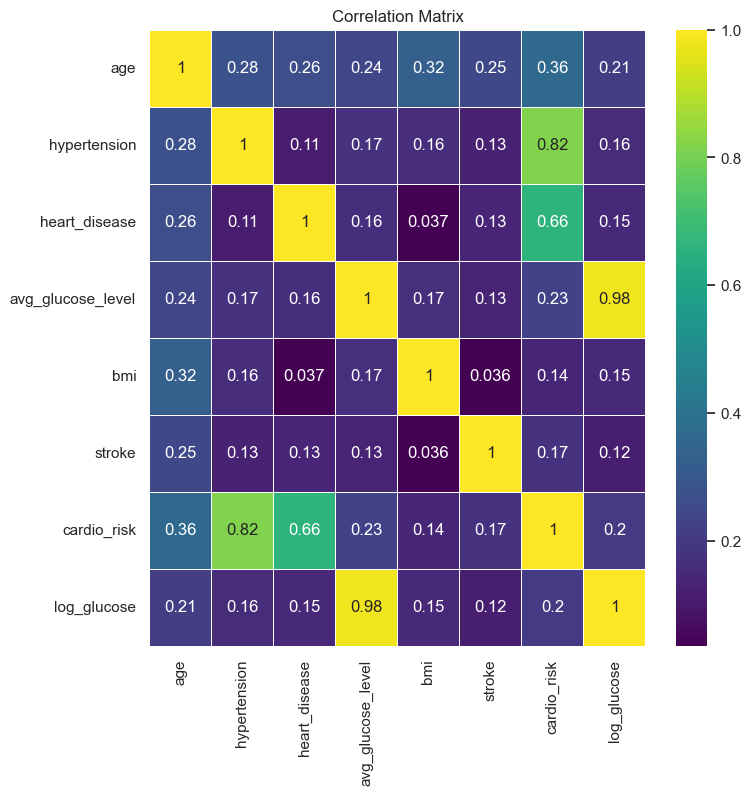

In [60]:
plt.figure(figsize=(8, 8))
corr_matrix = stroke_prediction.select_dtypes(include=['number']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='viridis', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

`Feature Selection and Data Splitting`

In [61]:
X = stroke_prediction.drop(['stroke'], axis=1)
y = stroke_prediction['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



`Encoding Categorical Features Using ColumnTransformer and OneHotEncoder`

In [62]:
num_col = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'cardio_risk', 'log_glucose']
cat_col = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'bmi_category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col)
    ]
)

#### `Model Training, Evaluation and Cross validation`

#### `Logistic Regression`

In [63]:
lr_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('lr', LogisticRegression(class_weight='balanced', random_state=42))
])

lr_pipe.fit(X_train, y_train)

lr_y_pred = lr_pipe.predict(X_test)
print(lr_y_pred)

[0 0 0 ... 0 0 0]


In [64]:
lr_model = {
    'LOGISTIC REGRESSION': lr_pipe
}

for name, model in lr_model.items():
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    lr_y_pred = model.predict(X_test)
    lr_y_prob = model.predict_proba(X_test)[:, 1]


# train and test score
print(f'\n{name}\n')
print(f'\n==== Training Score ==== \n {train_score:.3f}')
print(f'\n==== Test Score ==== \n {test_score:.3f}')

# model accuracy
accuracy = accuracy_score(y_test, lr_y_pred)
print(f'\n==== Model Accuracy ==== \n {accuracy:.3f}')

# prediction probability
print(f'\n==== Prediction Probability ==== \n {lr_y_prob}')

# classification report
report = classification_report(y_test, lr_y_pred)
print(f'\n==== Classification Report ==== \n {report}')

# confusion matrix
cm = confusion_matrix(y_test, lr_y_pred)
print(f'\n ==== Confusion matrix ==== \n {cm}')

# roc auc score
ras = roc_auc_score(y_test, lr_y_prob)
print(f'\n==== Roc Auc Score ==== \n {ras:.3f}')

# logistic regression cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = cross_val_score(lr_pipe, X, y, cv=skf, scoring='accuracy')
print(f'\n ==== Logistic Regression Cross Validation ==== \n {lr_cv}')
print(f'\n ==== Mean / Standard Deviation Cross Validation ==== \n {lr_cv.mean():.3f} (+/-) {lr_cv.std() * 2:.3f}')


LOGISTIC REGRESSION


==== Training Score ==== 
 0.750

==== Test Score ==== 
 0.761

==== Model Accuracy ==== 
 0.761

==== Prediction Probability ==== 
 [0.42405293 0.14789428 0.08234961 ... 0.16392492 0.03509499 0.29360184]

==== Classification Report ==== 
               precision    recall  f1-score   support

           0       0.99      0.76      0.86       972
           1       0.15      0.80      0.25        50

    accuracy                           0.76      1022
   macro avg       0.57      0.78      0.55      1022
weighted avg       0.95      0.76      0.83      1022


 ==== Confusion matrix ==== 
 [[738 234]
 [ 10  40]]

==== Roc Auc Score ==== 
 0.850

 ==== Logistic Regression Cross Validation ==== 
 [0.76418787 0.74755382 0.74853229 0.7553816  0.74168297]

 ==== Mean / Standard Deviation Cross Validation ==== 
 0.751 (+/-) 0.015


`Confusion Matrix`

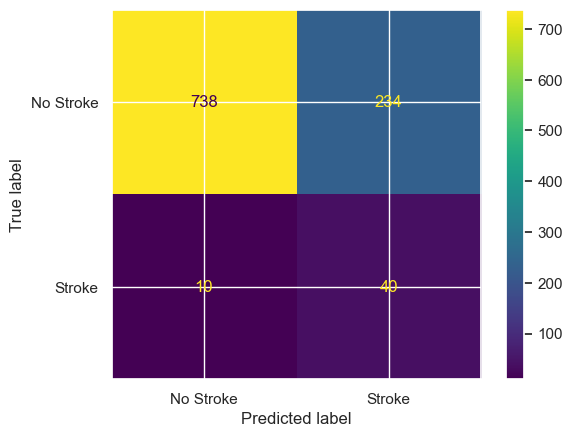

In [65]:
cm = confusion_matrix(y_test, lr_y_pred)
display = ConfusionMatrixDisplay(cm, display_labels=['No Stroke', 'Stroke'])
display.plot(cmap='viridis')
plt.show()

`Roc Curve Display`

<Figure size 1500x500 with 0 Axes>

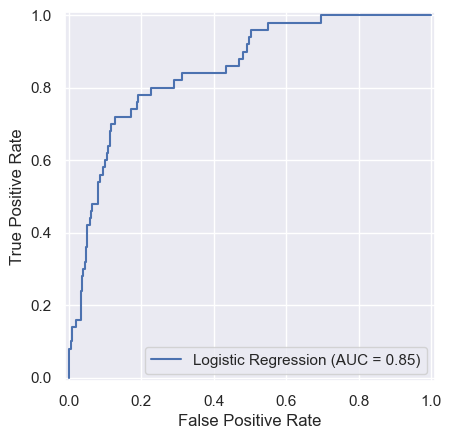

In [66]:
plt.figure(figsize=(15, 5))
fpr, tpr, thresholds = metrics.roc_curve(y_test, lr_y_prob)
lr_roc_auc = metrics.auc(fpr, tpr)
disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=lr_roc_auc, name='Logistic Regression')
disp.plot()
plt.show()

#### `RandomForestClassifier`

In [67]:
rfc_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state= 42)),
    ('rfc', RandomForestClassifier(class_weight='balanced', random_state=42))
])

rfc_pipe.fit(X_train, y_train)
rfc_y_pred = rfc_pipe.predict(X_test)

print(rfc_y_pred)

[0 0 0 ... 0 0 0]


In [68]:
rfc_model = {
    'RANDOMFORESTCLASSIFIER': rfc_pipe
}


# train and test score
for name, model in rfc_model.items():
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    rfc_y_pred = model.predict(X_test)
    rfc_y_prob = model.predict_proba(X_test)[:, 1]


print(f'\n{name}\n')
print(f'\n ==== Training Score ==== \n {train_score:.3f}')
print(f' \n ==== Test Score ==== \n {test_score:.3f}')

# model accuracy
accuracy = accuracy_score(y_test, rfc_y_pred)
print(f'\n ==== Model Accuracy ==== \n {accuracy:.3f}')

# prediction probability
print(f'\n==== Prediction Probability ==== \n {rfc_y_prob}')

# classification report
report = classification_report(y_test, rfc_y_pred)
print(f'\n ==== Classification Report ==== \n {report}')

# confusion matrix
cm = confusion_matrix(y_test, rfc_y_pred)
print(f'\n ==== Confusion Matrix ==== \n {cm}')

# roc auc score
ras = roc_auc_score(y_test, rfc_y_prob)
print(f'\n ==== Roc Auc Score ==== \n {ras:.3f}')

# randomforestclassifier cross validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfc_cv = cross_val_score(rfc_pipe, X, y, scoring='accuracy')

print(f'\n ==== RandomForestClasifier Cross Validation ==== \n {rfc_cv}')
print(f'\n ==== Mean / Standard Deviation Cross Validation ==== \n {rfc_cv.mean():.3f} (+/-) {rfc_cv.std() * 2:.3f}')


RANDOMFORESTCLASSIFIER


 ==== Training Score ==== 
 1.000
 
 ==== Test Score ==== 
 0.933

 ==== Model Accuracy ==== 
 0.933

==== Prediction Probability ==== 
 [0.01 0.   0.   ... 0.04 0.   0.03]

 ==== Classification Report ==== 
               precision    recall  f1-score   support

           0       0.95      0.98      0.97       972
           1       0.15      0.08      0.11        50

    accuracy                           0.93      1022
   macro avg       0.55      0.53      0.54      1022
weighted avg       0.91      0.93      0.92      1022


 ==== Confusion Matrix ==== 
 [[950  22]
 [ 46   4]]

 ==== Roc Auc Score ==== 
 0.775

 ==== RandomForestClasifier Cross Validation ==== 
 [0.92759295 0.92563601 0.9295499  0.94227006 0.93542074]

 ==== Mean / Standard Deviation Cross Validation ==== 
 0.932 (+/-) 0.012


`Confusion Matrix`

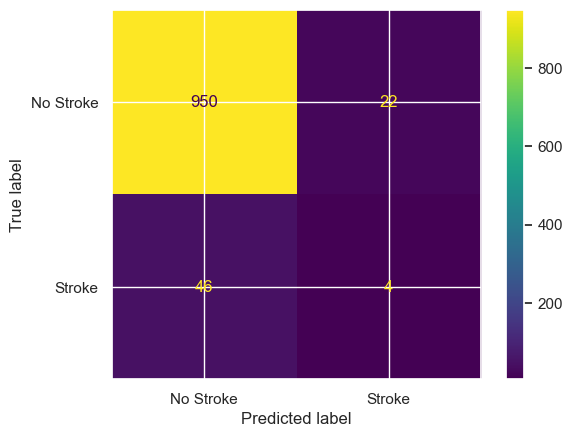

In [69]:
cm = confusion_matrix(y_test, rfc_y_pred)

display = ConfusionMatrixDisplay(cm, display_labels=['No Stroke', 'Stroke'])
display.plot(cmap='viridis')
plt.show()

`Roc Curve Display`

<Figure size 1500x500 with 0 Axes>

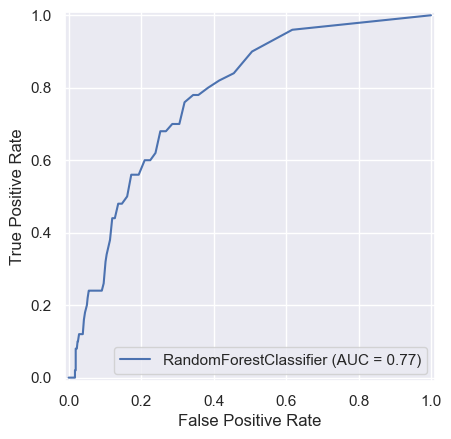

In [70]:
plt.figure(figsize=(15, 5))
fpr, tpr, thresholds = metrics.roc_curve(y_test, rfc_y_prob)
rfc_roc_auc = metrics.auc(fpr, tpr)
disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=rfc_roc_auc, name='RandomForestClassifier')
disp.plot()
plt.show()

#### `K-NeighborsClassifier`

In [71]:
knc_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state= 42)),
    ('knc', KNeighborsClassifier(weights='distance'))
])

knc_pipe.fit(X_train, y_train)
knc_y_pred = knc_pipe.predict(X_test)

print(knc_y_pred)

[0 0 0 ... 0 0 0]


In [72]:
knc_model = {
    'K-NEIGHBORS CLASSIFIER': knc_pipe
}

# train and test score
for name, model in knc_model.items():
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    knc_y_pred = model.predict(X_test)
    knc_y_prob = model.predict_proba(X_test)[:, 1]

print(f'\n{name}\n')
print(f'\n ==== Training Score ==== \n {train_score:.3f}')
print(f' \n ==== Test Score ==== \n {test_score:.3f}')

# model accuracy
accuracy = accuracy_score(y_test, knc_y_pred)
print(f'\n ==== Model Accuracy ==== \n {accuracy:.3f}')

# prediction probability
print(f'\n==== Prediction Probability ==== \n {knc_y_prob}')

# classification report
report = classification_report(y_test, knc_y_pred)
print(f'\n ==== Classification Report ==== \n {report}')

# confusion matrix
cm = confusion_matrix(y_test, knc_y_pred)
print(f'\n ==== Confusion Matrix ==== \n {cm}')

# roc auc score
ras = roc_auc_score(y_test, knc_y_prob)
print(f'\n ==== Roc Auc Score ==== \n {ras:.3f}')

# k-neighbors cross validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knc_cv = cross_val_score(knc_pipe, X, y, scoring='accuracy')

print(f'\n ==== K-Neighbors Classifier Cross Validation ==== \n {knc_cv}')
print(f'\n ==== Mean / Standard Deviation Cross Validation ==== \n {knc_cv.mean():.3f} (+/-) {knc_cv.std() * 2:.3f}')


K-NEIGHBORS CLASSIFIER


 ==== Training Score ==== 
 1.000
 
 ==== Test Score ==== 
 0.833

 ==== Model Accuracy ==== 
 0.833

==== Prediction Probability ==== 
 [0. 0. 0. ... 0. 0. 0.]

 ==== Classification Report ==== 
               precision    recall  f1-score   support

           0       0.96      0.86      0.91       972
           1       0.12      0.38      0.18        50

    accuracy                           0.83      1022
   macro avg       0.54      0.62      0.54      1022
weighted avg       0.92      0.83      0.87      1022


 ==== Confusion Matrix ==== 
 [[832 140]
 [ 31  19]]

 ==== Roc Auc Score ==== 
 0.685

 ==== K-Neighbors Classifier Cross Validation ==== 
 [0.8072407  0.81409002 0.81311155 0.84540117 0.84148728]

 ==== Mean / Standard Deviation Cross Validation ==== 
 0.824 (+/-) 0.032


`Confusion Matrix`

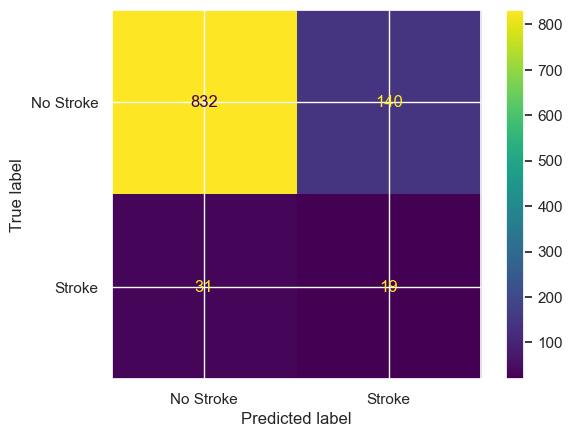

In [73]:
cm = confusion_matrix(y_test, knc_y_pred)

display = ConfusionMatrixDisplay(cm, display_labels=['No Stroke', 'Stroke'])
display.plot(cmap='viridis')
plt.show()

`Roc Curve Display`

<Figure size 1500x500 with 0 Axes>

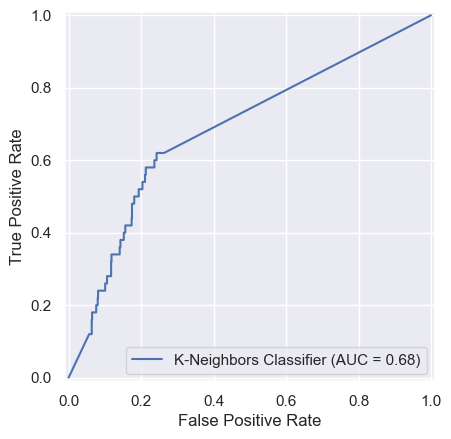

In [74]:
plt.figure(figsize=(15, 5))
fpr, tpr, thresholds = metrics.roc_curve(y_test, knc_y_prob)
knc_roc_auc = metrics.auc(fpr, tpr)
disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=knc_roc_auc, name='K-Neighbors Classifier')
disp.plot()
plt.show()

#### `Support Vector Classifier`

In [75]:
svc_pipe = Pipeline([
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state= 42)),
    ('svc', SVC(class_weight='balanced', gamma='auto', random_state=42))
])

svc_pipe.fit(X_train, y_train)
svc_y_pred = svc_pipe.predict(X_test)

print(svc_y_pred)

[0 0 0 ... 0 0 0]


In [76]:
svc_model = {
    'SUPPORT VECTOR CLASSIFIER': svc_pipe
}

# train and test score
for name, model in svc_model.items():
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    svc_y_pred = model.predict(X_test)
    decision = model.decision_function(X_test)


print(f'\n{name}\n')
print(f'\n ==== Training Score ==== \n {train_score:.3f}')
print(f' \n ==== Test Score ==== \n {test_score:.3f}')

# model accuracy
accuracy = accuracy_score(y_test, svc_y_pred)
print(f'\n ==== Model Accuracy ==== \n {accuracy:.3f}')

# decision function
print(f'\n==== Decision Function ==== \n {decision}')

# classification report
report = classification_report(y_test, svc_y_pred)
print(f'\n ==== Classification Report ==== \n {report}')

# confusion matrix
cm = confusion_matrix(y_test, svc_y_pred)
print(f'\n ==== Confusion Matrix ==== \n {cm}')

# roc auc score
ras = roc_auc_score(y_test, decision)
print(f'\n ==== Roc Auc Score ==== \n {ras:.3f}')

# support vector classifier cross validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svc_cv = cross_val_score(svc_pipe, X, y, scoring='accuracy')

print(f'\n ==== Support Vector Classifier Cross Validation ==== \n {svc_cv}')
print(f'\n ==== Mean / Standard Deviation Cross Validation ==== \n {svc_cv.mean():.3f} (+/-) {svc_cv.std() * 2:.3f}')


SUPPORT VECTOR CLASSIFIER


 ==== Training Score ==== 
 0.777
 
 ==== Test Score ==== 
 0.766

 ==== Model Accuracy ==== 
 0.766

==== Decision Function ==== 
 [-0.53590689 -1.31722416 -2.0665651  ... -1.43435091 -2.96576958
 -0.70968357]

 ==== Classification Report ==== 
               precision    recall  f1-score   support

           0       0.98      0.77      0.86       972
           1       0.13      0.68      0.22        50

    accuracy                           0.77      1022
   macro avg       0.56      0.73      0.54      1022
weighted avg       0.94      0.77      0.83      1022


 ==== Confusion Matrix ==== 
 [[749 223]
 [ 16  34]]

 ==== Roc Auc Score ==== 
 0.814

 ==== Support Vector Classifier Cross Validation ==== 
 [0.76027397 0.76418787 0.73483366 0.75733855 0.77984344]

 ==== Mean / Standard Deviation Cross Validation ==== 
 0.759 (+/-) 0.029


`Confusion Matrix`

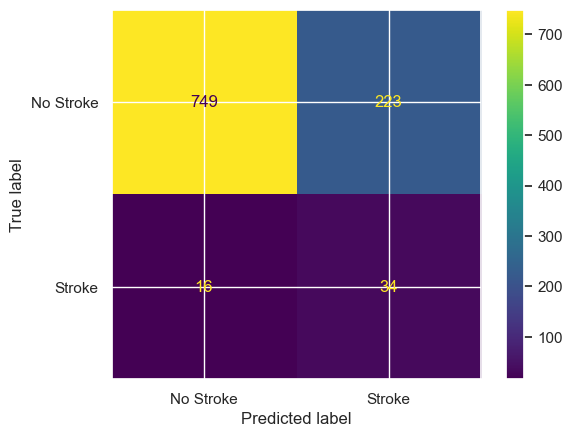

In [77]:
cm = confusion_matrix(y_test, svc_y_pred)

display = ConfusionMatrixDisplay(cm, display_labels=['No Stroke', 'Stroke'])
display.plot(cmap='viridis')
plt.show()

`Roc Curve Display`

<Figure size 1500x500 with 0 Axes>

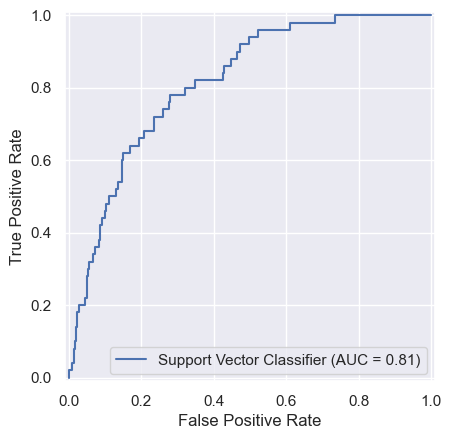

In [78]:
plt.figure(figsize=(15, 5))
fpr, tpr, thresholds = metrics.roc_curve(y_test, decision)
svc_roc_auc = metrics.auc(fpr, tpr)
disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=svc_roc_auc, name='Support Vector Classifier')
disp.plot()
plt.show()